# Классификация текста 
## Ссылки

https://www.youtube.com/watch?v=AwdawjHJstU - Классификация текста | Обработка естественного языка</br>
https://www.youtube.com/watch?v=55Iyei3bkKk&list=PLtPJ9lKvJ4ohZpMV9Ml-DPtMSXPFNl6Sz</br>

https://www.youtube.com/watch?v=-2O0ODmnw1o - NLP cookbook: анализируем тексты на Python с минимальными знаниями о машинном обучении

# 0. Импорты

In [92]:
import pandas as pd
from sentence_transformers import SentenceTransformer
import nltk
from nltk.corpus import stopwords
import string
import re
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt


# 1. Загрузка датасета

In [93]:
df = pd.read_json("data/data.txt", lines=True)
df

,text,tags,schema_name,table_name
0,"1 1 1 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47923
1,"1 1 1 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710
2,"2 2 2 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710
3,"3 3 3 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710
4,"4 4 4 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710
...,...,...,...,...
18419,996 996 982 20231117_110117.jpg 2023-11-17 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876
18420,997 997 983 20231121_100442.jpg 2023-11-21 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876
18421,998 998 984 20231121_095847.jpg 2023-11-21 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876
18422,99 99 101 117 4.jpg 2023-11-16 00:00:00+00 13:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876


In [94]:
final_df = df.copy()

# Мультиклассовая классификация на основе имён таблиц

In [95]:
final_df['full_table_name'] = final_df['schema_name'] + '.' + final_df['table_name']
# final_df['class_name'] =  final_df['tags'].apply(lambda x: '/'.join(x))
final_df['class_id'] = pd.factorize(final_df['full_table_name'])[0] # для Multiclass классификации на основе имени таблицы
# также сделать дял multilable classification. Если нет тегов, то брать имя таблицы
final_df

,text,tags,schema_name,table_name,full_table_name,class_id
0,"1 1 1 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47923,_46379._47923,0
1,"1 1 1 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,_46379._58710,1
2,"2 2 2 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,_46379._58710,1
3,"3 3 3 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,_46379._58710,1
4,"4 4 4 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,_46379._58710,1
...,...,...,...,...,...,...
18419,996 996 982 20231117_110117.jpg 2023-11-17 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,_46379._47876,20
18420,997 997 983 20231121_100442.jpg 2023-11-21 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,_46379._47876,20
18421,998 998 984 20231121_095847.jpg 2023-11-21 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,_46379._47876,20
18422,99 99 101 117 4.jpg 2023-11-16 00:00:00+00 13:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,_46379._47876,20


# Анализ датасета
## Распределение данных по классам

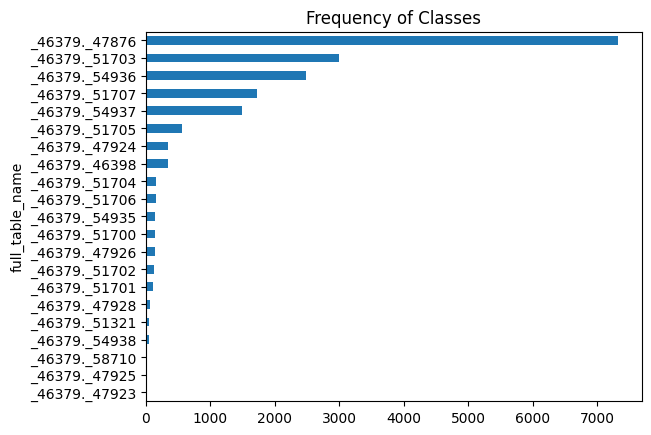

In [96]:
# узнаем кол-во примеров в каждом классе
final_df["full_table_name"].value_counts(ascending=True).plot.barh()
plt.title("Frequency of Classes")
plt.show()

In [97]:
final_df["full_table_name"].value_counts(ascending=True)

full_table_name
_46379._47923       1
_46379._47925       1
_46379._58710       6
_46379._54938      46
_46379._51321      50
_46379._47928      64
_46379._51701     108
_46379._51702     133
_46379._47926     144
_46379._51700     146
_46379._54935     148
_46379._51706     156
_46379._51704     164
_46379._46398     342
_46379._47924     343
_46379._51705     558
_46379._54937    1483
_46379._51707    1727
_46379._54936    2485
_46379._51703    2992
_46379._47876    7327
Name: count, dtype: int64

## Распределение кол-ва токенов в классах

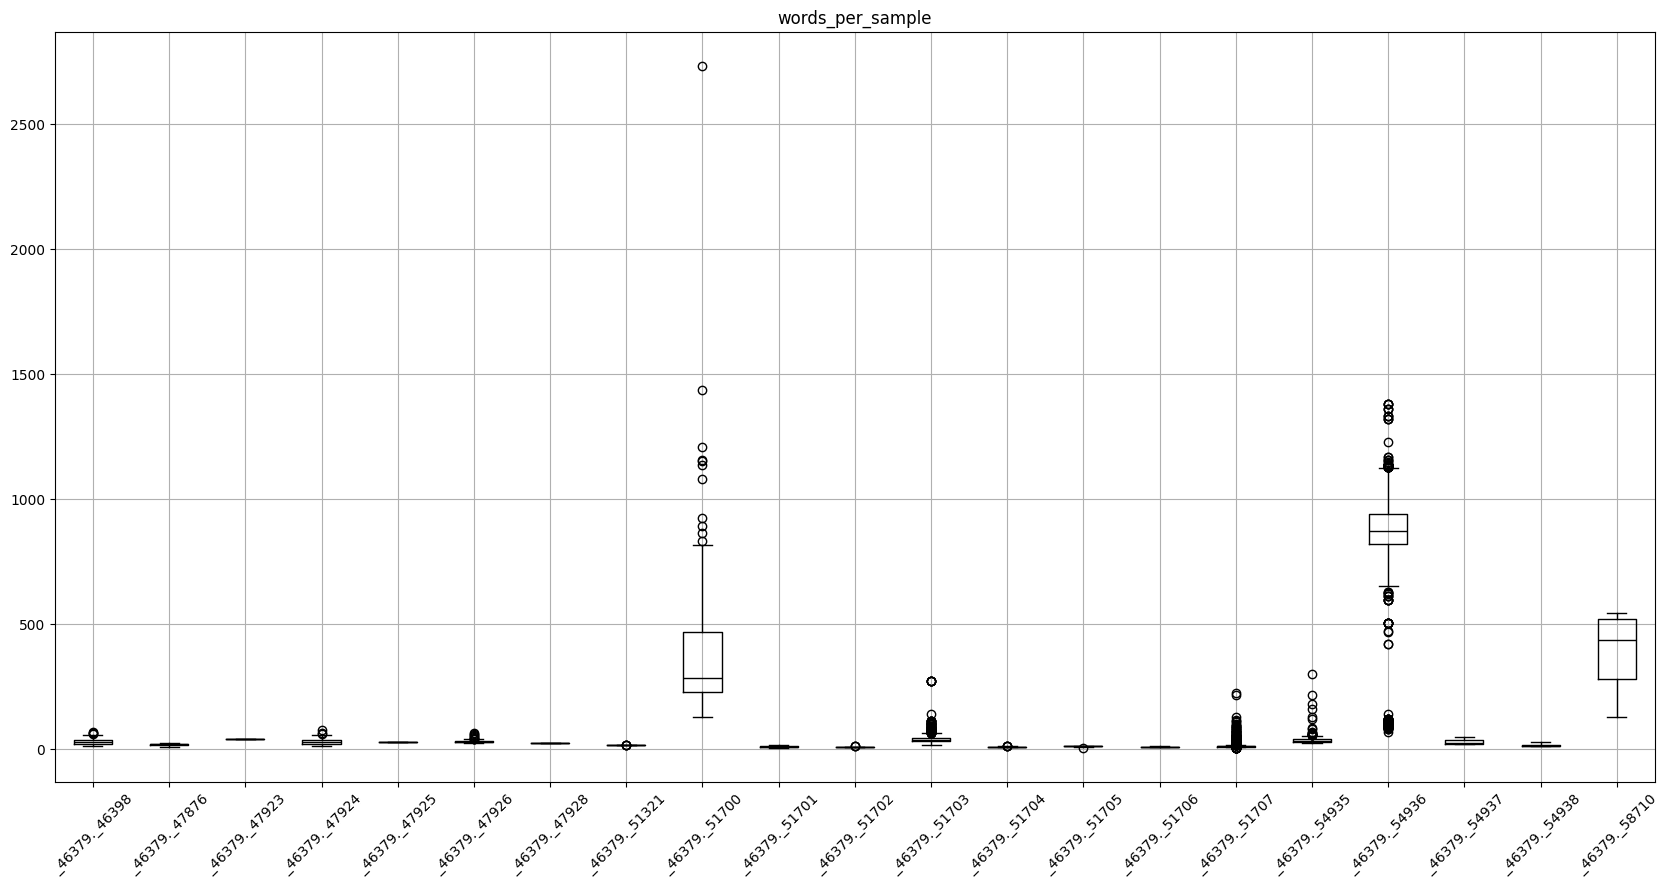

In [98]:
# кол-во слов в каждом классе
final_df["words_per_sample"] = final_df["text"].str.split().apply(len)
final_df.boxplot("words_per_sample", by="full_table_name", grid=True,
showfliers=True, color="black", figsize=(20, 10), rot=45)
plt.suptitle("")
plt.xlabel("")
plt.show()


# Формирование датафрейма. Предобработка данных. Получение эмбедингов.Общие стандартные шаги для начала работы

Итоговые рекомендации:
Прекратите удалять стоп-words и, возможно, прекратите приводить к нижнему регистру. Просто проведите базовую очистку: удалите лишние пробелы, спецсимволы, HTML-теги, если они есть, и т.д.

Никакой дополнительной токенизации не нужно. Просто передавайте строку в model.encode(). Доверяйте встроенному пайплайну SentenceTransformer. Он отлично спроектирован и сам выполнит всю необходимую низкоуровневую работу. Ваша задача — подать на вход качественный, связный текст

In [99]:
# Загрузка модели Sentence-BERT (выбираем multilingual версию)
model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')

In [100]:
# Загрузка стоп-слов (один раз при старте)
# nltk.download('stopwords')
# stop_words = set(stopwords.words('russian')) # Загрузка стоп-слов (один раз при старте)

In [101]:
# Функция для очистки текста
def clean_text(text):
    if not isinstance(text, str):
        return ""
    
    # Удаление URL
    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text, flags=re.MULTILINE)
    # Удаление цифр и специальных символов
    text = re.sub(r'\d+', ' ', text)
    # Удаление пунктуации
    # text = text.translate(str.maketrans('', '', string.punctuation))
    translator = str.maketrans(string.punctuation, ' ' * len(string.punctuation))
    text = text.translate(translator)
    # Приведение к нижнему регистру (не всегда обязательно, возможно ухудшит качество)
    text = text.lower()
    # Удаление стоп-слов (не всегда  обязательно, возможно ухудшит качество)
    # stop_words = set(stopwords.words('russian'))
    words = text.split()
    # words = [word for word in words if word not in stop_words and len(word) > 2]
    return ' '.join(words)

In [102]:
# Функция для получения имени сервиса. Именем сервиса является номер на 2-ой позиции в списке тегов
def get_service_name(list_of_tags):
    # если недостаточное кол-во тегов -> нет сервиса -> возвращаем пустую строку
    if len(list_of_tags) < 2:
        return ''
    service_name = list_of_tags[1]
    return service_name

In [103]:
# Функция для получения осмысленного имени таблицы. Именем таблицы является последний номер в списке тегов
def get_table_info_name(tags, table_name):

    # если недостаточное кол-во тегов -> нет сервиса -> возвращаем пустую строку
    if len(tags) == 0:
        # return ''
        return table_name
    table_info_name = tags[-1] # получаем последнюю строку
    return table_info_name

In [104]:
# Функция для обработки чанка с очисткой текста
def process_chunk(chunk):
    """Генерирует эмбеддинги для чанка с предварительной очисткой"""
    # Очищаем тексты
    cleaned_texts = chunk['text'].apply(clean_text).tolist()
    # получаем имена сервисов
    service_names = chunk['tags'].apply(get_service_name).tolist()
    # получаем осмысленное имя таблицы
    table_info_name = chunk.apply(lambda row: get_table_info_name(row['tags'], row['full_table_name']), axis=1).tolist()
    # chunk.apply(lambda row: get_table_info_name(row))
    # table_info_name = chunk.apply(get_table_info_name).tolist()
    # Генерируем эмбеддинги для всех текстов в чанке
    embeddings = model.encode(cleaned_texts, 
                            show_progress_bar=False,
                            convert_to_numpy=True)
    
    # Добавляем результаты в чанк
    chunk['cleaned_text'] = cleaned_texts
    chunk['embeddings'] = list(embeddings)
    chunk['service_name'] = service_names
    chunk['table_info_name'] = table_info_name
    return chunk

In [105]:
final_df

,text,tags,schema_name,table_name,full_table_name,class_id,words_per_sample
0,"1 1 1 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47923,_46379._47923,0,39
1,"1 1 1 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,_46379._58710,1,130
2,"2 2 2 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,_46379._58710,1,372
3,"3 3 3 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,_46379._58710,1,252
4,"4 4 4 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,_46379._58710,1,504
...,...,...,...,...,...,...,...
18419,996 996 982 20231117_110117.jpg 2023-11-17 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,_46379._47876,20,13
18420,997 997 983 20231121_100442.jpg 2023-11-21 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,_46379._47876,20,22
18421,998 998 984 20231121_095847.jpg 2023-11-21 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,_46379._47876,20,22
18422,99 99 101 117 4.jpg 2023-11-16 00:00:00+00 13:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,_46379._47876,20,17


In [106]:
# Размер чанка (подбирайте под ваши ресурсы)
CHUNK_SIZE = 1000  
# Инициализация прогресс-бара
pbar = tqdm(total=len(final_df), desc="Обработка датафрейма")
# Обработка по чанкам
results = []
for i in range(0, len(final_df), CHUNK_SIZE):
    chunk = final_df.iloc[i:i + CHUNK_SIZE].copy()
    processed_chunk = process_chunk(chunk)
    results.append(processed_chunk)
    pbar.update(len(chunk))
pbar.close()

# Сборка финального датафрейма
final_df = pd.concat(results, ignore_index=True)

Обработка датафрейма: 100%|██████████| 18424/18424 [00:13<00:00, 1409.00it/s]


In [107]:
final_df

,text,tags,schema_name,table_name,full_table_name,class_id,words_per_sample,cleaned_text,embeddings,service_name,table_info_name
0,"1 1 1 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47923,_46379._47923,0,39,часть территории национального парка лосиный о...,"[0.3547967, 0.16676068, 0.07977914, -0.0005325...",440 Особо охраняемые природные территории,Границы ООПТ
1,"1 1 1 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,_46379._58710,1,130,часть территории национального парка лосиный о...,"[0.22239774, 0.15734524, 0.013664918, -0.04089...",440 Особо охраняемые природные территории,"Зонирование, Режимы охраны и использования ООПТ"
2,"2 2 2 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,_46379._58710,1,372,часть территории национального парка лосиный о...,"[0.28809375, 0.14398257, 0.04981663, -0.006072...",440 Особо охраняемые природные территории,"Зонирование, Режимы охраны и использования ООПТ"
3,"3 3 3 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,_46379._58710,1,252,часть территории национального парка лосиный о...,"[0.28809375, 0.14398257, 0.04981663, -0.006072...",440 Особо охраняемые природные территории,"Зонирование, Режимы охраны и использования ООПТ"
4,"4 4 4 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,_46379._58710,1,504,часть территории национального парка лосиный о...,"[0.36440247, 0.12335314, 0.059311002, -0.05470...",440 Особо охраняемые природные территории,"Зонирование, Режимы охраны и использования ООПТ"
...,...,...,...,...,...,...,...,...,...,...,...
18419,996 996 982 20231117_110117.jpg 2023-11-17 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,_46379._47876,20,13,jpg photo зелао уч комплексный заказник зелено...,"[0.15561336, 0.32526222, 0.0925827, 0.00283530...",440 Особо охраняемые природные территории,Фотофиксация
18420,997 997 983 20231121_100442.jpg 2023-11-21 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,_46379._47876,20,22,jpg photo юзао и юао пип битцевский лес участо...,"[0.0332909, 0.2387227, 0.2250042, 0.11981269, ...",440 Особо охраняемые природные территории,Фотофиксация
18421,998 998 984 20231121_095847.jpg 2023-11-21 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,_46379._47876,20,22,jpg photo юзао и юао пип битцевский лес участо...,"[0.0332909, 0.2387227, 0.2250042, 0.11981269, ...",440 Особо охраняемые природные территории,Фотофиксация
18422,99 99 101 117 4.jpg 2023-11-16 00:00:00+00 13:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,_46379._47876,20,17,jpg photo зелао уч комплексный заказник зелено...,"[0.15561336, 0.32526222, 0.0925827, 0.00283530...",440 Особо охраняемые природные территории,Фотофиксация


# Класификация по таблицам

In [108]:
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [112]:
final_df['class_id'].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20])

In [119]:
final_df['class_id']

0         0
1         1
2         1
3         1
4         1
         ..
18419    20
18420    20
18421    20
18422    20
18423    20
Name: class_id, Length: 18424, dtype: int64

In [120]:
# Проблема в том, что final_df['embeddings'] содержит массивы или списки, а не плоские числовые значения. Вот как это исправить:
X = final_df['embeddings']
# Преобразуем список/серию эмбеддингов в 2D numpy array
X = np.vstack(X.values)  # или np.array(X.tolist())
y = final_df['class_id'].values


In [121]:
# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [122]:
# Обучение классификатора
classifier = LogisticRegression(max_iter=1000, random_state=42)
classifier.fit(X_train, y_train)
    
# Предсказание и оценка
y_pred = classifier.predict(X_test)
    
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9978290366350068

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       1.00      1.00      1.00         1
           3       1.00      1.00      1.00        13
           4       1.00      0.97      0.98        30
           5       1.00      1.00      1.00       484
           6       1.00      1.00      1.00       297
           7       0.91      0.91      0.91        11
           8       0.94      1.00      0.97        30
           9       1.00      0.92      0.96        25
          10       1.00      1.00      1.00        23
          11       1.00      1.00      1.00        22
          12       1.00      1.00      1.00       655
          13       1.00      0.94      0.97        34
          14       0.99      1.00      1.00       118
          15       1.00      1.00      1.00        29
          16       0.99      1.00      0.99        73
          17       1.00     

D:\Artem\Magistrature\1_sem\intellg_systems_and_techno\labs\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\Artem\Magistrature\1_sem\intellg_systems_and_techno\labs\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\Artem\Magistrature\1_sem\intellg_systems_and_techno\labs\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this 